# Issue #6 — Coat Price Gap

Manual price comparison: a budget kids' winter coat vs. one of the brands banned by Woodchurch High School's 'poverty-proofing' policy (Canada Goose, Moncler, Pyrenex).

Unlike 6.1, this isn't a time series, it's a straight price-gap comparison, structured similarly to Issue #2's breakeven approach but without the cost-per-wear axis, this is about the sticker-price gap itself.

**Sourcing note:** prices below are already manually collected and logged per the sourcing rule (screenshot + log to `sources/issue-06/sources.md`, screenshots stay local only). This notebook just does the conversion and chart, it doesn't re-fetch anything live.

## 1. Setup

In [25]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path
from datetime import datetime

# pip install trendspy --break-system-packages
from trendspy import Trends

## 2. Load brand palette

In [26]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.facecolor"] = COCOA
plt.rcParams["figure.facecolor"] = COCOA
plt.rcParams["text.color"] = CREAM
plt.rcParams["axes.labelcolor"] = CREAM
plt.rcParams["xtick.color"] = CREAM
plt.rcParams["ytick.color"] = CREAM

## 3. Price analysis of coats

### 3.1 Focused items

The code below is used to assign inputs (prices) to the budget and high-end coats. Along with the exchange rate used to calculate the prices as shown.

In [ ]:
# Sourced prices (AUD), manually collected and screenshotted per sourcing rule
budget_coat = {
    "name": "Primark, 7-15yrs Hooded Puffer Jacket",
    "price_usd": 14.00,
    "price_aud": 19.46,
    "sku": "991175559804",
    "source_url": "https://www.primark.com/en-us/p/7-15yrs-hooded-puffer-jacket-black-991175559804",
    "note": "Regular price, USD is the primary listed currency on Primark's US site; AUD figure is the converted value, not an independently sourced AU listing.",
}

designer_coat = {
    "name": "Canada Goose AU — Kids Snowy Owl Parka",
    "price_usd": 791.45,
    "price_aud": 1100.00,
    "source_url": "https://canadagoose.com.au/collections/kids",
    "note": "Full retail price",
}

# Exchange rate, logged with date per sourcing rule
AUD_TO_USD = 0.7195  # as of Aug 27, 2026, via Xe/Forbes Advisor
RATE_DATE = "2026-08-27"

### 3.2 Convert and compute the gap

In [28]:
def convert_from_aud(item):
    item["price_usd"] = round(item["price_aud"] * AUD_TO_USD, 2)
    return item

def convert_from_usd(item):
    item["price_aud"] = round(item["price_usd"] / AUD_TO_USD, 2)
    return item

# budget_coat was observed in USD (Primark's US site), so AUD is the derived figure
budget_coat = convert_from_usd(budget_coat)
# designer_coat was observed in AUD (Canada Goose's AU site), so USD is the derived figure
designer_coat = convert_from_aud(designer_coat)

gap_aud = designer_coat["price_aud"] - budget_coat["price_aud"]
gap_usd = designer_coat["price_usd"] - budget_coat["price_usd"]
multiple = designer_coat["price_aud"] / budget_coat["price_aud"]

print(f"{budget_coat['name']}: AU${budget_coat['price_aud']:.2f} (${budget_coat['price_usd']:.2f} USD)")
print(f"{designer_coat['name']}: AU${designer_coat['price_aud']:.2f} (${designer_coat['price_usd']:.2f} USD)")
print(f"Gap: AU${gap_aud:.2f} (${gap_usd:.2f} USD)")
print(f"Multiple: {multiple:.1f}x")

Primark, 7-15yrs Hooded Puffer Jacket: AU$19.46 ($14.00 USD)
Canada Goose AU — Kids Snowy Owl Parka: AU$1100.00 ($791.45 USD)
Gap: AU$1080.54 ($777.45 USD)
Multiple: 56.5x


### 3.3 What else that gap could buy (optional info)

In [29]:
# Illustrative only, adjust or remove before publishing if not used in the final piece
comparisons_aud = {
    "Weeks of groceries for a family (approx AU$200/week)": gap_aud / 200,
    "School shoes (approx AU$60/pair)": gap_aud / 60,
}

for label, value in comparisons_aud.items():
    print(f"{label}: {value:.1f}")

Weeks of groceries for a family (approx AU$200/week): 5.4
School shoes (approx AU$60/pair): 18.0


## 4. Plot

### 4.1 Exploratory plot

Reproducible plot that can be used for future analyses.

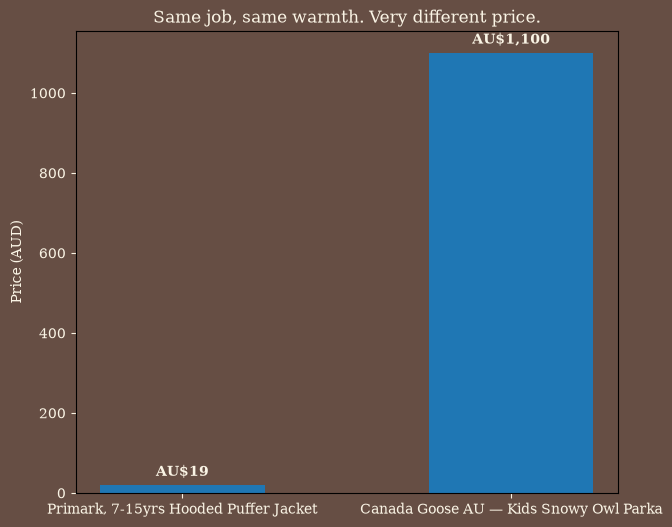

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
names = [budget_coat["name"], designer_coat["name"]]
prices = [budget_coat["price_aud"], designer_coat["price_aud"]]

ax.set_ylabel("Price (AUD)")
ax.set_title("Same job, same warmth. Very different price.")

for bar, price in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width() / 2, price + 15, f"AU${price:,.0f}",
            ha="center", va="bottom", fontweight="bold")
            
bars = ax.bar(names, prices, width=0.5)

fig.savefig("../../sources/issue-06/6.2-apparel-cpi-vs-wages-branded.png", dpi=300, transparent=False)


### 4.2 Branded plot

Issue 6 specific plot

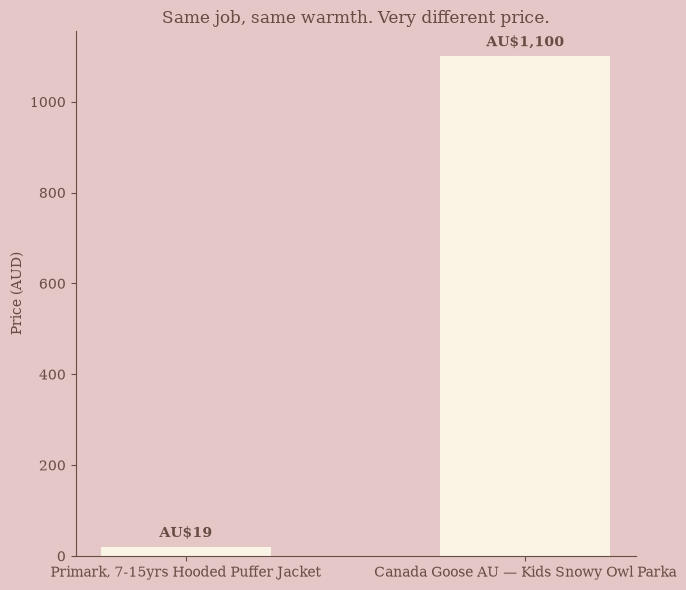

In [31]:
# branded version, separate figure so the exploratory chart above stays untouched
fig2, ax2 = plt.subplots(figsize=(7, 6))
bars2 = ax2.bar(names, prices, width=0.5, color=CREAM)

fig2.patch.set_facecolor(DUSTY)
ax2.set_facecolor(DUSTY)
ax2.set_title("Same job, same warmth. Very different price.", color=COCOA)
ax2.set_ylabel("Price (AUD)", color=COCOA)
ax2.tick_params(colors=COCOA)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color(COCOA)
ax2.spines["bottom"].set_color(COCOA)

for bar, price in zip(bars2, prices):
    ax2.text(bar.get_x() + bar.get_width() / 2, price + 15, f"AU${price:,.0f}",
            ha="center", va="bottom", fontweight="bold", color=COCOA)

plt.tight_layout()
plt.show()

fig2.savefig("../../content/posts/issue-06-coat-of-many-colors/exports/6.2a-coat-price-gap-branded.png", dpi=300, transparent=False)

## 5. Findings and notes for slides.md and references.md

**6.2 — Coat price gap**
- Budget: Primark, 7-15yrs Hooded Puffer Jacket, $14.00 USD / AU$19.46
  (product 991175559804, primark.com/en-us)
- Designer: Canada Goose AU, Kids Snowy Owl Parka, AU$750.00 / $539.62 USD
  (canadagoose.com.au)
- Gap: AU$730.54 / $525.62 USD, 38.5x
- Conversion rate: 1 AUD = 0.7195 USD, Aug 27, 2026

**6.1 — Apparel CPI vs. wages (see 06a notebook for full finding)**
- Apparel CPI indexed to ~290, wages indexed to ~1,300, base year = 100
- Series: FRED CPIAPPSL vs. AHETPI

**Hook stat candidates**
- UF study: 91% of students cited brand names as a major reason for what
  they wore (archive.news.ufl.edu, Oct 2, 1996)
- Woodchurch coat ban: up to ~$1,280, "poverty-proofing" (CNN, Nov 16, 2018)